In [6]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import joblib
import re
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score, confusion_matrix, classification_report

data_dir = '/content/drive/MyDrive/AML_Dataset/AML_Dataset'

model = joblib.load(f'{data_dir}/aml_lgbm_baseline.joblib')
train_df = pd.read_parquet(f'{data_dir}/train_features.parquet')
test_df = pd.read_parquet(f'{data_dir}/test_features.parquet')

print("Loaded. Train:", train_df.shape, "Test:", test_df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded. Train: (7189442, 20) Test: (1784557, 20)


In [7]:
target_col = 'Is Laundering'
drop_cols = ['Timestamp', 'Account', 'Account.1', target_col]
categorical_cols = ['From Bank', 'To Bank', 'Payment Format', 'Payment Currency', 'Receiving Currency']

for col in categorical_cols:
    train_df[col] = train_df[col].astype('category')
    test_df[col] = test_df[col].astype('category')

X_train = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])
X_test = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns])
y_test = test_df[target_col]
X_test = X_test[list(X_train.columns)]

y_proba = model.predict_proba(X_test)[:, 1]
print("Predictions generated for", len(y_proba), "test transactions")

Predictions generated for 1784557 test transactions


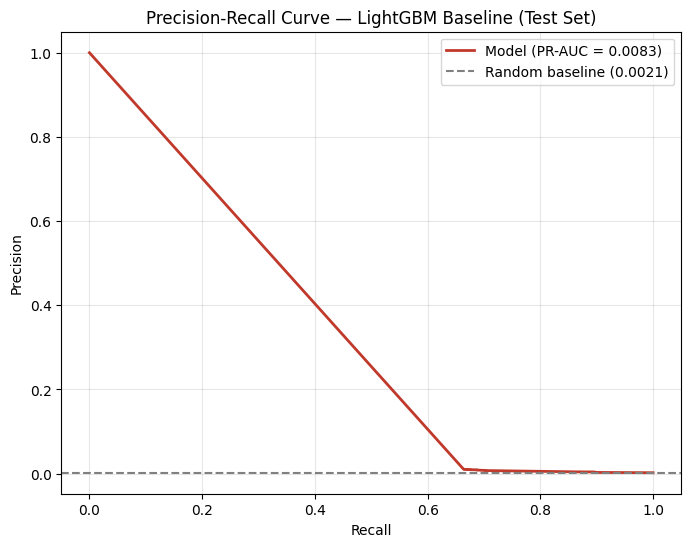

PR-AUC: 0.0083 | ROC-AUC: 0.7921 | Random baseline: 0.0021 | 3.9x better than random


In [8]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
baseline = y_test.mean()

plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'Model (PR-AUC = {pr_auc:.4f})', color='#c0392b', linewidth=2)
plt.axhline(baseline, linestyle='--', color='gray', label=f'Random baseline ({baseline:.4f})')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curve — LightGBM Baseline (Test Set)')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig('pr_curve.png', dpi=150)
plt.show()

print(f"PR-AUC: {pr_auc:.4f} | ROC-AUC: {roc_auc:.4f} | Random baseline: {baseline:.4f} | {pr_auc/baseline:.1f}x better than random")

In [9]:
target_recall = 0.5
valid_idx = np.where(recall[:-1] >= target_recall)[0]
best_idx = valid_idx[np.argmax(precision[:-1][valid_idx])]
chosen_threshold = thresholds[best_idx]

print(f"Chosen threshold: {chosen_threshold:.4f}")
print(f"Precision: {precision[best_idx]:.4f}, Recall: {recall[best_idx]:.4f}")

y_pred = (y_proba >= chosen_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\nTN: {tn:,} | FP: {fp:,} | FN: {fn:,} | TP: {tp:,}")
print("\n" + classification_report(y_test, y_pred, digits=4, target_names=['Legitimate', 'Illicit']))

Chosen threshold: 1.0000
Precision: 0.0104, Recall: 0.6638

TN: 1,540,990 | FP: 239,772 | FN: 1,276 | TP: 2,519

              precision    recall  f1-score   support

  Legitimate     0.9992    0.8654    0.9275   1780762
     Illicit     0.0104    0.6638    0.0205      3795

    accuracy                         0.8649   1784557
   macro avg     0.5048    0.7646    0.4740   1784557
weighted avg     0.9971    0.8649    0.9255   1784557



In [10]:
with open('/content/HI-Small_Patterns.txt', 'r') as f:
    lines = f.readlines()

pattern_rows = []
current_pattern = None
for line in lines:
    line = line.strip()
    if line.startswith("BEGIN LAUNDERING ATTEMPT"):
        current_pattern = line.split("-")[1].split(":")[0].strip()
    elif line.startswith("END LAUNDERING ATTEMPT"):
        current_pattern = None
    elif current_pattern and re.match(r'^\d{4}/\d{2}/\d{2}', line):
        parts = line.split(",")
        pattern_rows.append({
            "Timestamp": parts[0], "From Bank": parts[1], "Account": parts[2],
            "To Bank": parts[3], "Account.1": parts[4], "Pattern": current_pattern
        })

patterns_df = pd.DataFrame(pattern_rows)
patterns_df["Timestamp"] = pd.to_datetime(patterns_df["Timestamp"], format="%Y/%m/%d %H:%M")
patterns_df['From Bank'] = patterns_df['From Bank'].astype(int).astype(str)
patterns_df['To Bank'] = patterns_df['To Bank'].astype(int).astype(str)

print(f"Parsed {len(patterns_df)} labeled illicit transactions")
print(patterns_df["Pattern"].value_counts())

Parsed 3209 labeled illicit transactions
Pattern
GATHER       716
FAN          660
SCATTER      626
STACK        466
CYCLE        287
BIPARTITE    263
RANDOM       191
Name: count, dtype: int64


In [11]:
results_df = test_df[['Timestamp', 'From Bank', 'To Bank', 'Account', 'Account.1', 'Is Laundering']].copy()
results_df['From Bank'] = results_df['From Bank'].astype(str)
results_df['To Bank'] = results_df['To Bank'].astype(str)
results_df['y_pred'] = y_pred
results_df['y_proba'] = y_proba

merged = results_df.merge(patterns_df, on=['Timestamp', 'From Bank', 'To Bank', 'Account', 'Account.1'], how='left')
illicit_matched = merged[(merged['Is Laundering'] == 1) & (merged['Pattern'].notna())]

print(f"Matched {len(illicit_matched)} of {merged['Is Laundering'].sum()} illicit test transactions to a pattern")

pattern_recall = illicit_matched.groupby('Pattern', observed=True).apply(
    lambda g: pd.Series({'total_illicit': len(g), 'caught': g['y_pred'].sum(), 'recall': g['y_pred'].mean()}),
    include_groups=False
).sort_values('recall', ascending=False)

print("\n=== Recall by Laundering Pattern ===")
print(pattern_recall)

Matched 2269 of 3795 illicit test transactions to a pattern

=== Recall by Laundering Pattern ===
           total_illicit  caught    recall
Pattern                                   
SCATTER            437.0   419.0  0.958810
FAN                446.0   425.0  0.952915
STACK              243.0   225.0  0.925926
BIPARTITE          118.0   109.0  0.923729
CYCLE              189.0   174.0  0.920635
GATHER             669.0   615.0  0.919283
RANDOM             167.0   148.0  0.886228


## Cost Trade-off Analysis

At the chosen threshold, the model correctly identifies 2,519 of 3,795 illicit transactions in the test set (66.4% recall), while missing 1,276 real laundering cases. However, this comes at the cost of 239,772 false positives — legitimate transactions incorrectly flagged for review. In a real compliance setting, this volume of false alarms is operationally unsustainable: even a well-staffed team cannot manually review hundreds of thousands of flagged transactions over a 10-day window without severe alert fatigue, which risks analysts deprioritizing genuine alerts over time. This highlights the core trade-off of the current baseline: raising the threshold reduces false alarms but lets more real laundering through, while lowering it catches more laundering at an unmanageable investigative cost. A production deployment would likely need a much higher-precision model, tiered alert prioritization (e.g. using the model's probability score to rank cases), or additional features to narrow the false-positive pool before this baseline could be operationally viable.

In [12]:
!pip install shap -q
import shap
print("SHAP installed:", shap.__version__)

SHAP installed: 0.52.0


In [13]:
import numpy as np

# Sample 5000 rows from X_test for speed (SHAP is slow on 1.78M rows)
sample_idx = np.random.RandomState(42).choice(len(X_test), size=5000, replace=False)
X_sample = X_test.iloc[sample_idx]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

print("SHAP values computed. Shape:", np.array(shap_values).shape)

SHAP values computed. Shape: (5000, 16)


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


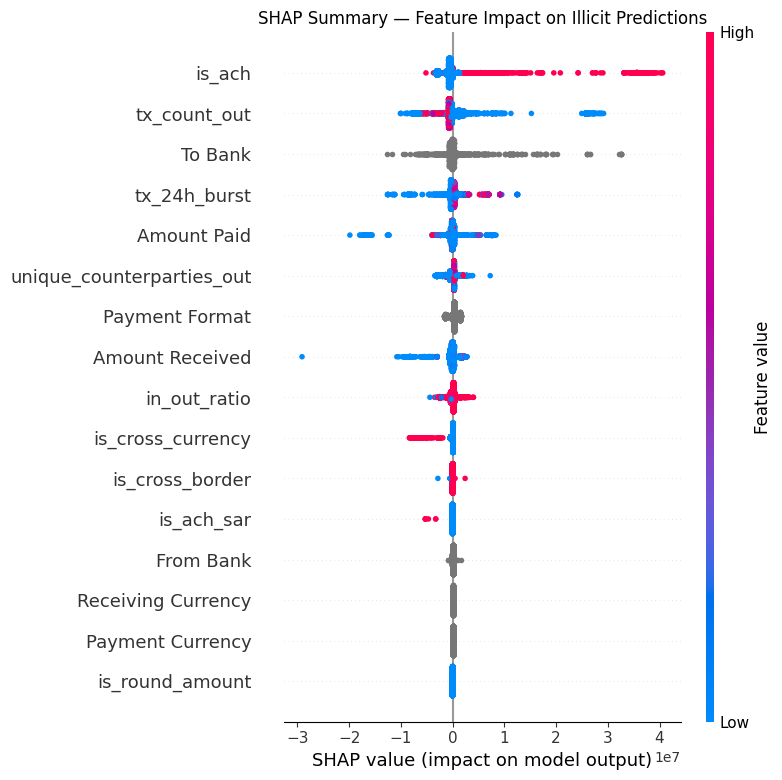

In [14]:
import matplotlib.pyplot as plt

plt.figure()
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("SHAP Summary — Feature Impact on Illicit Predictions")
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

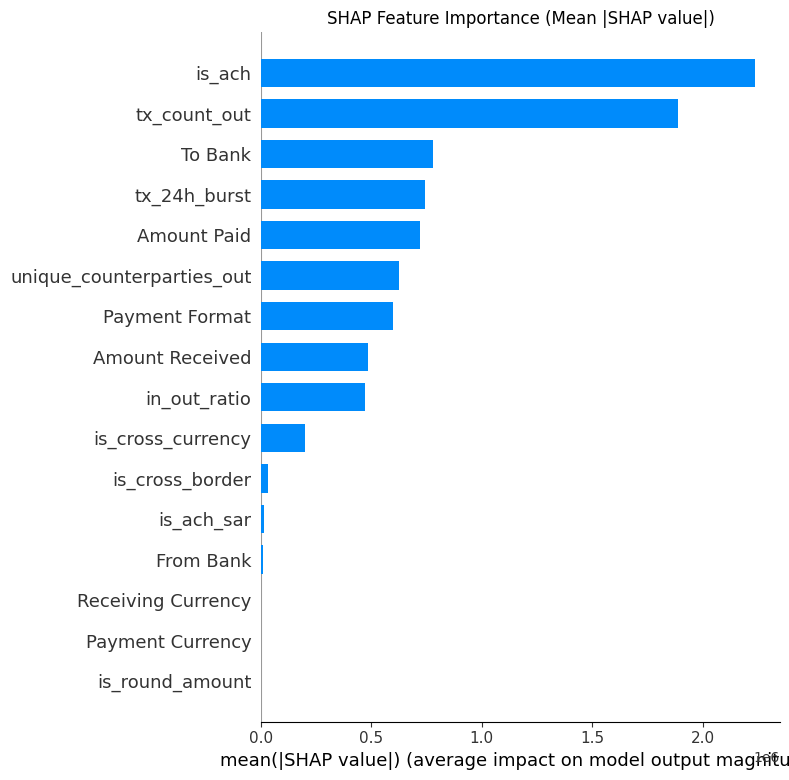

In [15]:
plt.figure()
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Mean |SHAP value|)")
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

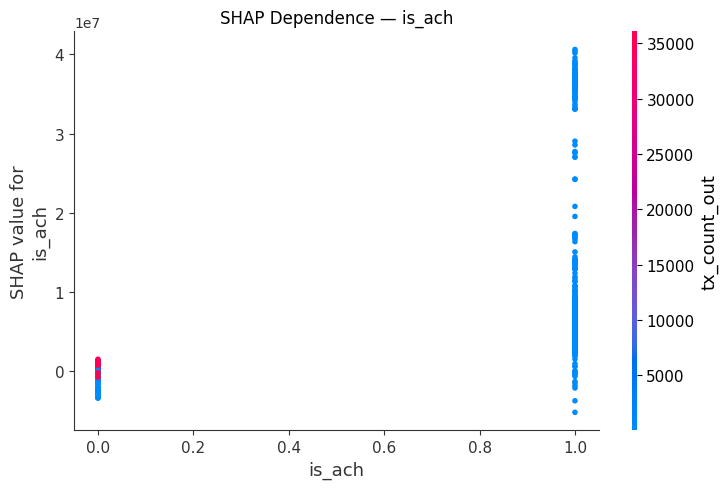

In [16]:
plt.figure()
shap.dependence_plot("is_ach", shap_values, X_sample, show=False)
plt.title("SHAP Dependence — is_ach")
plt.tight_layout()
plt.savefig('shap_dependence_is_ach.png', dpi=150, bbox_inches='tight')
plt.show()

## SHAP Interpretation

The SHAP analysis shows that `is_ach` (whether a transaction uses the ACH payment format) is the single strongest driver of illicit predictions, followed by `tx_count_out` (an account's total outgoing transaction count) and `To Bank`. This aligns with real AML compliance intuition: ACH transfers are commonly exploited in layering schemes because they are fast, low-friction, and harder to reverse than other payment rails, making them attractive for moving illicit funds quickly through multiple accounts. Similarly, a high `tx_count_out` reflects unusually frequent outgoing activity from a single account — a hallmark of fan-out or gather-scatter laundering patterns, where funds are rapidly distributed to obscure their origin. The dependence plot confirms that being an ACH transaction (is_ach = 1) sharply increases the model's predicted illicit probability compared to non-ACH transactions, reinforcing that payment format is a compliance-relevant signal rather than noise. These findings suggest that compliance teams reviewing model flags should pay particular attention to high-frequency ACH activity, as it represents the clearest behavioral signature the model has learned to associate with laundering.